# §6 Device Productivity — the chip as the unit of analysis

Answers the draft's questions directly: how fast are new chips taken up, how
long do they stay productive, and how many papers / citations does each chip
support?

* **6.1 Paper support** — papers per device model, full and fractional credit.
* **6.2 Productive half-life** — years from a model's peak share of
  accelerator-using papers until it sustainedly falls below half of that peak,
  with bootstrap CIs and right-censoring. Compared against the 3–5 year grant
  cycle, which is the policy-relevant benchmark for buy-vs-rent decisions.
* **6.3 Adoption lag** — release date → first mention → 10th/100th paper, by
  hardware generation: is diffusion into science speeding up?
* **6.4 Citation and disruption support** — 5-year citations (`i_5`) and CD
  index (`cd_5`) per model, full and fractional.

> Descriptive attribution, not causal: a paper crediting a chip is not evidence
> the chip caused the result. Fractional credit (1/k across a paper's k models)
> is reported alongside full credit throughout.

Inputs: `python -m accelscan.denominator` and `python -m accelscan.compute`.

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from accelscan.config import BUCKET, OUT_PREFIX
from accelscan.normalize import canonicalize_column
from accelscan.registry import load_registry
from accelscan.s3 import mentions_glob, storage_options
from accelscan.plotting import install_year_tick_fix

install_year_tick_fix()   # no fractional year ticks (2007.5) on any figure

## Knobs

In [2]:
MODEL_TAG, PROMPT_VERSION = 'qwen3-14b', 'p1'
YEAR_MIN, YEAR_MAX = 2005, 2025
USED_ONLY = True            # restrict to used-in-this-work mentions
MIN_PAPERS_MODEL = 100      # eligibility for lifecycle estimates (plan: 100; robustness 50/250)
SMOOTH = 3                  # years in the moving average for half-life
GRANT_CYCLE = (3, 5)        # years, for the policy benchmark band
BOOTSTRAP = 200
LOCAL_ANALYTIC = None

PAL = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9', '#999999',
       '#000000', '#984EA3', '#44AA99']
reg = load_registry(); so = storage_options()

## Load paper×model observations + outcomes

In [3]:
base = (LOCAL_ANALYTIC or
        f's3://{BUCKET}/{OUT_PREFIX}/analytic/{reg.version}/{PROMPT_VERSION}/{MODEL_TAG}')
rd = (lambda n: pl.read_parquet(f'{base}/{n}.parquet')) if LOCAL_ANALYTIC else \
     (lambda n: pl.read_parquet(f'{base}/{n}.parquet', storage_options=so))
den = rd('denominator').select('corpusid', 'year', 'field')
cit = rd('citations')

m = (pl.scan_parquet(mentions_glob(MODEL_TAG, PROMPT_VERSION), storage_options=so)
     .filter(pl.col('status') == 'ok')
     .select('corpusid', 'model_normalized', 'manufacturer', 'usage_context')
     .collect())
if USED_ONLY:
    m = m.filter(pl.col('usage_context') == 'used-in-this-work')
m = canonicalize_column(m, reg).filter(pl.col('canonical_kind') == 'model')

meta = pl.DataFrame(
    [{'canonical_model': x.id, 'display': x.display, 'manufacturer_reg': x.manufacturer,
      'segment': x.segment, 'architecture': x.architecture,
      'release_year': int(x.release[:4]) if x.release else None,
      'release_ym': x.release, 'fp32_gflops': x.fp32_gflops}
     for x in reg.models.values() if x.kind == 'model'],
    schema={'canonical_model': pl.Utf8, 'display': pl.Utf8, 'manufacturer_reg': pl.Utf8,
            'segment': pl.Utf8, 'architecture': pl.Utf8, 'release_year': pl.Int32,
            'release_ym': pl.Utf8, 'fp32_gflops': pl.Float64})

# one row per (paper, model); fractional credit = 1/k over the paper's k models
pm = (m.select('corpusid', 'canonical_model').unique()
      .join(den, on='corpusid', how='inner')
      .filter(pl.col('year').is_between(YEAR_MIN, YEAR_MAX)))
pm = (pm.join(pm.group_by('corpusid').agg(k=pl.len()), on='corpusid')
      .with_columns(frac=1.0 / pl.col('k'))
      .join(meta, on='canonical_model', how='left')
      .join(cit.select('corpusid', 'citations_5y', 'disruption_5y', 'window_complete',
                       'has_outcomes'), on='corpusid', how='left'))
print(f'{pm.height:,} paper-model observations | {pm.n_unique("corpusid"):,} papers '
      f'| {pm.n_unique("canonical_model"):,} models')

197,376 paper-model observations | 179,975 papers | 534 models


## 6.1 Paper support per device model

104 models meet the >=100-paper eligibility bar


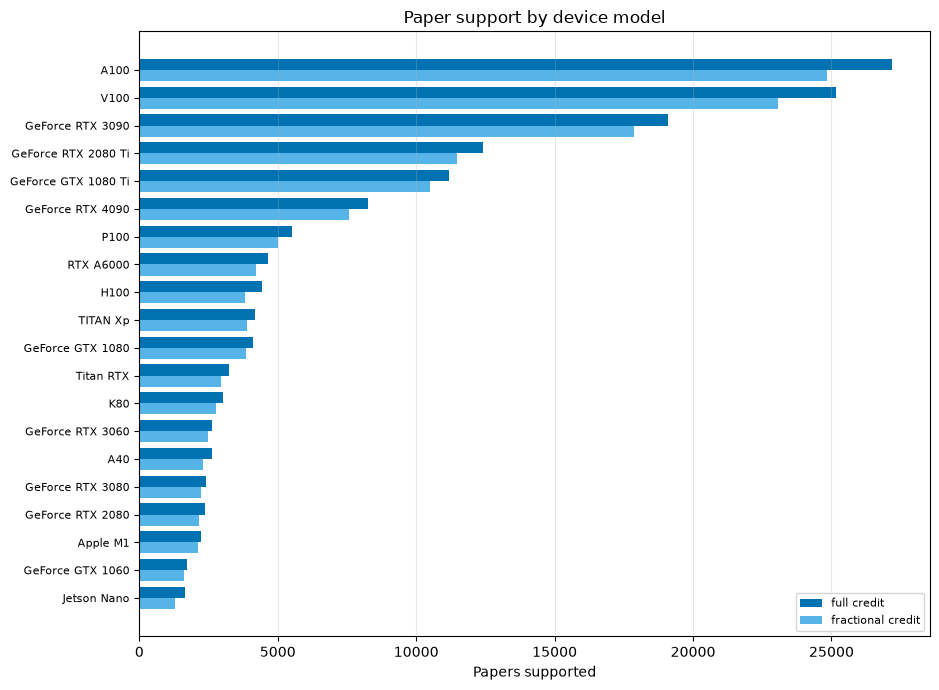

shape: (20, 5)
┌────────────────────────────┬──────────────┬─────────────┬─────────────┬────────────┐
│ display                    ┆ release_year ┆ papers_full ┆ papers_frac ┆ first_year │
│ ---                        ┆ ---          ┆ ---         ┆ ---         ┆ ---        │
│ str                        ┆ i32          ┆ u32         ┆ f64         ┆ i64        │
╞════════════════════════════╪══════════════╪═════════════╪═════════════╪════════════╡
│ NVIDIA A100                ┆ 2020         ┆ 27198       ┆ 24841.2     ┆ 2018       │
│ NVIDIA V100                ┆ 2017         ┆ 25172       ┆ 23062.7     ┆ 2014       │
│ NVIDIA GeForce RTX 3090    ┆ 2020         ┆ 19109       ┆ 17861.7     ┆ 2019       │
│ NVIDIA GeForce RTX 2080 Ti ┆ 2018         ┆ 12419       ┆ 11470.2     ┆ 2016       │
│ NVIDIA GeForce GTX 1080 Ti ┆ 2017         ┆ 11193       ┆ 10493.9     ┆ 2017       │
│ NVIDIA GeForce RTX 4090    ┆ 2022         ┆ 8256        ┆ 7584.4      ┆ 2020       │
│ NVIDIA P100               

In [4]:
sup = (pm.group_by('canonical_model', 'display', 'release_year', 'segment', 'architecture')
       .agg(papers_full=pl.len(), papers_frac=pl.col('frac').sum(),
            first_year=pl.col('year').min(), peak_year_raw=pl.col('year').mode().first())
       .sort('papers_full', descending=True))
elig = sup.filter(pl.col('papers_full') >= MIN_PAPERS_MODEL)
print(f'{elig.height} models meet the >={MIN_PAPERS_MODEL}-paper eligibility bar')
top = elig.head(20)
fig, ax = plt.subplots(figsize=(9.5, 7))
y = np.arange(top.height)
ax.barh(y - 0.2, top['papers_full'], 0.4, label='full credit', color='#0072B2')
ax.barh(y + 0.2, top['papers_frac'], 0.4, label='fractional credit', color='#56B4E9')
ax.set_yticks(y)
ax.set_yticklabels([d.replace('NVIDIA ', '') for d in top['display']], fontsize=8)
ax.invert_yaxis(); ax.set(xlabel='Papers supported', title='Paper support by device model')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()
with pl.Config(tbl_rows=25, fmt_str_lengths=40):
    print(top.select('display', 'release_year', 'papers_full',
                     pl.col('papers_frac').round(1), 'first_year'))

## 6.2 Productive half-life

A model's share of accelerator-using papers each year, `SMOOTH`-year moving
average. Peak year = argmax of the smoothed share. Half-life = first h such
that the smoothed share stays at or below half the peak for two consecutive
observed years. Models never crossing by the last year are **right-censored**
and reported as `H > x` rather than dropped (dropping them would bias half-lives
downward — the survivors are exactly the long-lived chips).

96 models: 55 with observed half-life, 41 right-censored
median observed half-life: 3.0 years


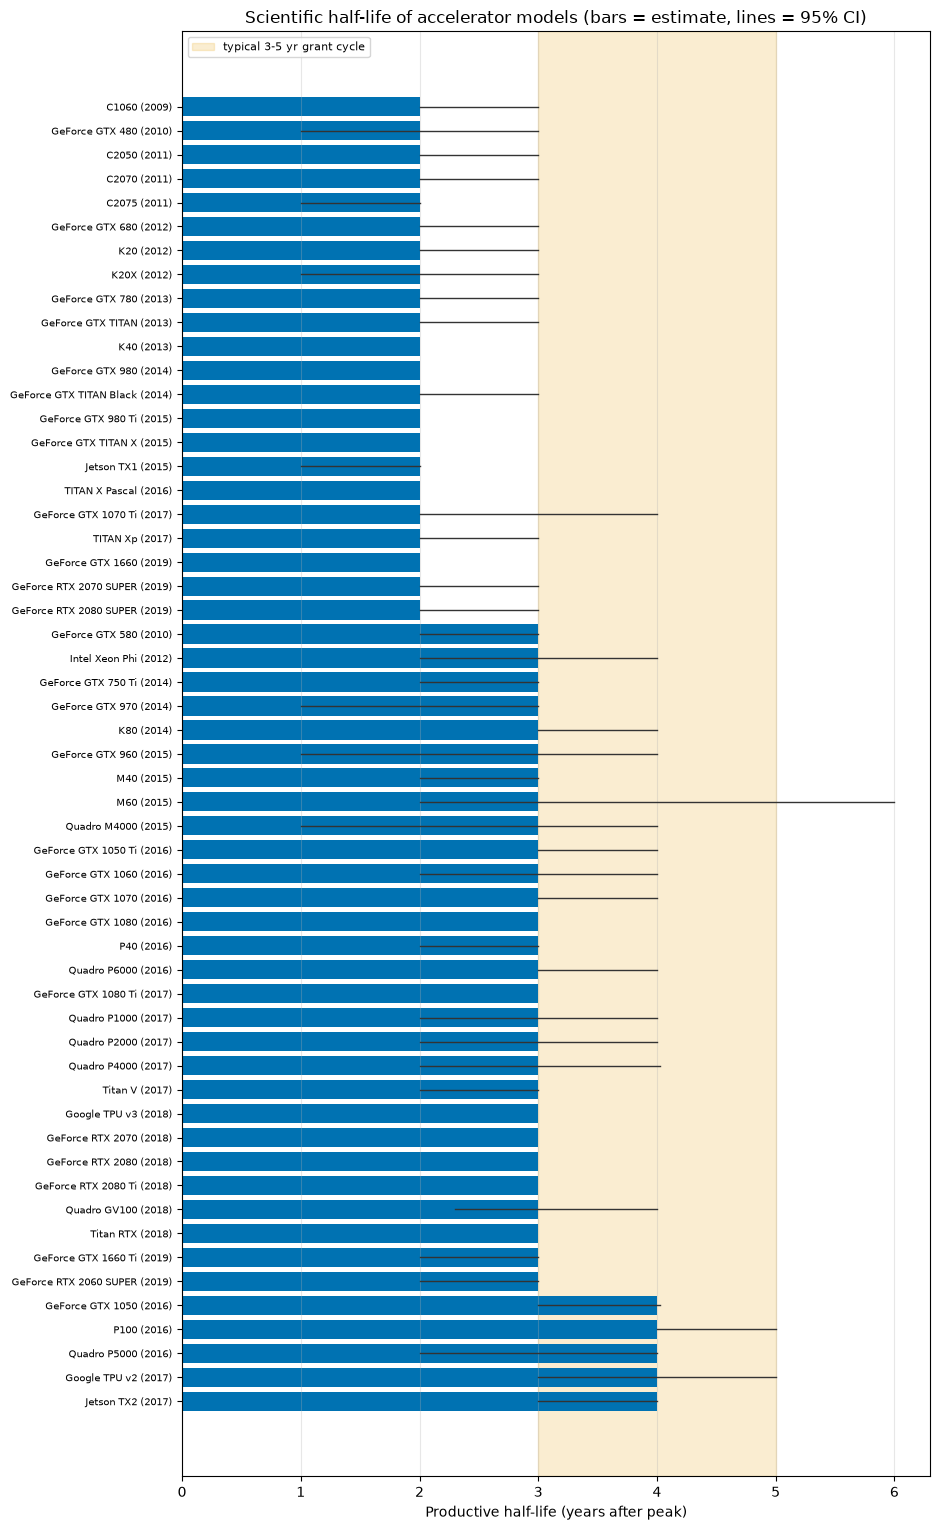

shape: (96, 7)
┌───────────────────┬──────────────┬───────────┬───────────────┬───────────┬──────────┬────────────┐
│ display           ┆ release_year ┆ peak_year ┆ years_to_peak ┆ half_life ┆ censored ┆ peak_share │
│ ---               ┆ ---          ┆ ---       ┆ ---           ┆ ---       ┆ ---      ┆ ---        │
│ str               ┆ i64          ┆ i64       ┆ i64           ┆ i64       ┆ bool     ┆ f64        │
╞═══════════════════╪══════════════╪═══════════╪═══════════════╪═══════════╪══════════╪════════════╡
│ NVIDIA C1060      ┆ 2009         ┆ 2010      ┆ 1             ┆ 2         ┆ false    ┆ 0.1664     │
│ NVIDIA GeForce    ┆ 2010         ┆ 2012      ┆ 2             ┆ 2         ┆ false    ┆ 0.1152     │
│ GTX 480           ┆              ┆           ┆               ┆           ┆          ┆            │
│ NVIDIA GeForce    ┆ 2010         ┆ 2012      ┆ 2             ┆ 3         ┆ false    ┆ 0.1031     │
│ GTX 580           ┆              ┆           ┆               ┆           ┆

In [5]:
per_year = pm.group_by('year').agg(accel_papers=pl.col('corpusid').n_unique())
shares = (pm.group_by('canonical_model', 'year').agg(k=pl.col('corpusid').n_unique())
          .join(per_year, on='year')
          .with_columns(share=pl.col('k') / pl.col('accel_papers')))

def smooth(v: np.ndarray, w: int = SMOOTH) -> np.ndarray:
    if w <= 1 or v.size < w:
        return v
    ker = np.ones(w) / w
    return np.convolve(v, ker, mode='same')

def half_life(years: np.ndarray, sh: np.ndarray, persist: int = 2):
    """-> (peak_year, peak_share, half_life or None if censored)"""
    sm = smooth(sh)
    pi = int(np.argmax(sm))
    peak, py = sm[pi], years[pi]
    thr = peak / 2
    below = 0
    for j in range(pi + 1, len(years)):
        below = below + 1 if sm[j] <= thr else 0
        if below >= persist:
            return py, peak, int(years[j - persist + 1] - py)
    return py, peak, None

rows = []
for mid in elig['canonical_model']:
    s = shares.filter(pl.col('canonical_model') == mid).sort('year')
    if s.height < 4:
        continue
    yy = s['year'].to_numpy(); vv = s['share'].to_numpy().astype(float)
    py, peak, hl = half_life(yy, vv)
    boots = []
    rng = np.random.default_rng(0)
    for _ in range(BOOTSTRAP):
        jitter = rng.poisson(np.maximum(s['k'].to_numpy(), 0)).astype(float)
        tot = s['accel_papers'].to_numpy().astype(float)
        _, _, h = half_life(yy, np.divide(jitter, tot, out=np.zeros_like(tot), where=tot > 0))
        if h is not None:
            boots.append(h)
    d = meta.filter(pl.col('canonical_model') == mid)
    rows.append({'canonical_model': mid, 'display': d['display'][0],
                 'release_year': d['release_year'][0], 'segment': d['segment'][0],
                 'peak_year': int(py), 'peak_share': float(peak),
                 'half_life': hl, 'censored': hl is None,
                 'hl_lo': float(np.percentile(boots, 2.5)) if boots else None,
                 'hl_hi': float(np.percentile(boots, 97.5)) if boots else None,
                 'years_to_peak': int(py - d['release_year'][0]) if d['release_year'][0] else None})
hl = pl.DataFrame(rows).sort('release_year', 'display')
obs = hl.filter(~pl.col('censored')).sort('half_life')
print(f'{hl.height} models: {obs.height} with observed half-life, '
      f'{hl.height - obs.height} right-censored')
print('median observed half-life:', obs['half_life'].median(), 'years')

fig, ax = plt.subplots(figsize=(9.5, max(4, 0.28 * obs.height)))
ax.axvspan(*GRANT_CYCLE, color='#E69F00', alpha=0.18, label='typical 3-5 yr grant cycle')
yy = np.arange(obs.height)
ax.barh(yy, obs['half_life'], color='#0072B2')
for i, (lo, hi, h) in enumerate(zip(obs['hl_lo'], obs['hl_hi'], obs['half_life'])):
    if lo is not None and hi is not None:
        ax.plot([lo, hi], [i, i], color='#333333', lw=1)
ax.set_yticks(yy)
ax.set_yticklabels([f"{d.replace('NVIDIA ','')} ({r})" for d, r in
                    zip(obs['display'], obs['release_year'])], fontsize=7)
ax.invert_yaxis()
ax.set(xlabel='Productive half-life (years after peak)',
       title='Scientific half-life of accelerator models (bars = estimate, lines = 95% CI)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()
with pl.Config(tbl_rows=40, fmt_str_lengths=34):
    print(hl.select('display', 'release_year', 'peak_year', 'years_to_peak',
                    'half_life', 'censored',
                    pl.col('peak_share').round(4)).sort('release_year'))

### Half-life diagnostics

The plan requires a diagnostic panel per reported half-life — raw share,
smoothed curve, peak, half-peak threshold, crossing year — so an automated
estimate cannot silently be wrong.

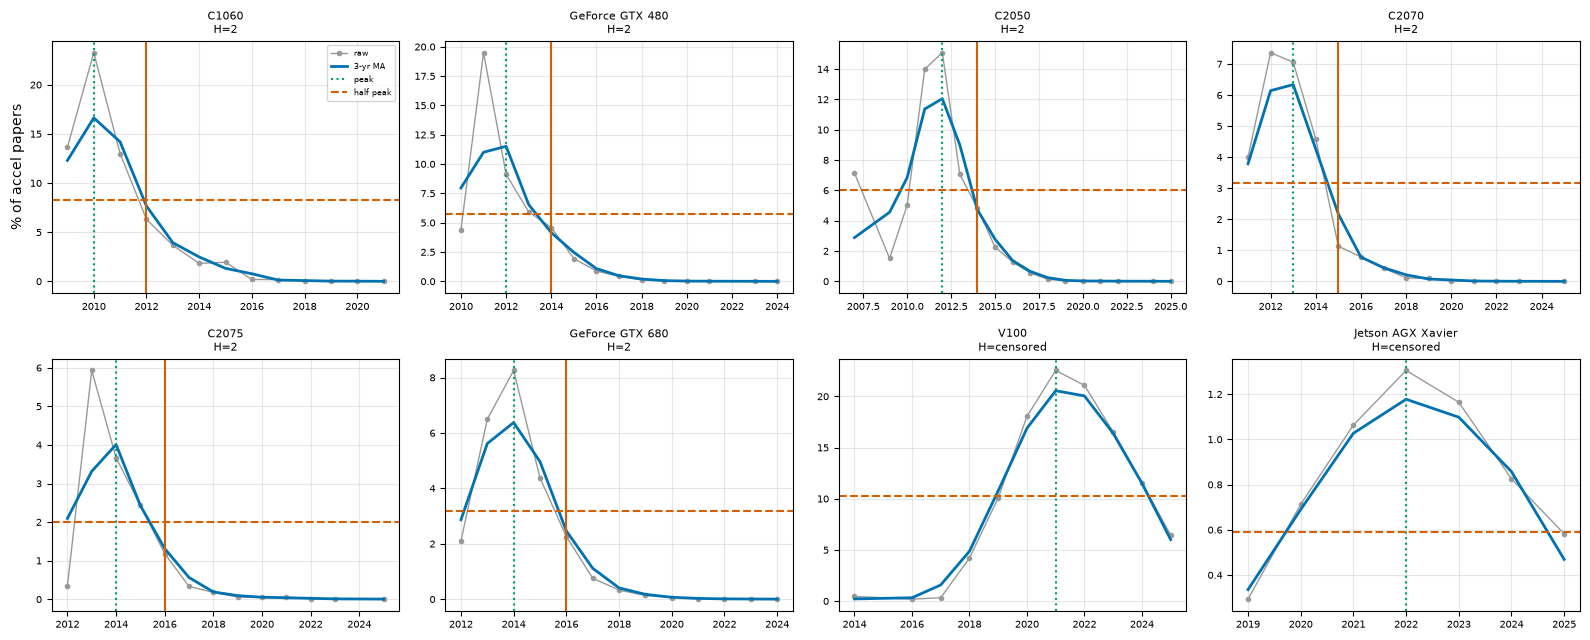

In [6]:
show = obs.head(6)['canonical_model'].to_list() + \
       hl.filter(pl.col('censored')).head(2)['canonical_model'].to_list()
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
for ax, mid in zip(axes.ravel(), show):
    s = shares.filter(pl.col('canonical_model') == mid).sort('year')
    yy = s['year'].to_numpy(); vv = s['share'].to_numpy().astype(float)
    r = hl.filter(pl.col('canonical_model') == mid).row(0, named=True)
    ax.plot(yy, 100 * vv, marker='.', color='#999999', lw=1, label='raw')
    ax.plot(yy, 100 * smooth(vv), color='#0072B2', lw=2, label=f'{SMOOTH}-yr MA')
    ax.axvline(r['peak_year'], color='#009E73', ls=':', label='peak')
    ax.axhline(100 * r['peak_share'] / 2, color='#D55E00', ls='--', label='half peak')
    if r['half_life'] is not None:
        ax.axvline(r['peak_year'] + r['half_life'], color='#D55E00', lw=1.5)
    ax.set_title(f"{r['display'].replace('NVIDIA ','')}\n"
                 f"H={'censored' if r['censored'] else r['half_life']}", fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.3)
axes[0, 0].set_ylabel('% of accel papers'); axes[0, 0].legend(fontsize=6)
plt.tight_layout(); plt.show()

## 6.3 Adoption lag by generation

Months from commercial release to first scientific mention, and to the 10th and
100th supporting paper. Plotted against release year: a downward slope means
science is absorbing each new generation faster than the last.

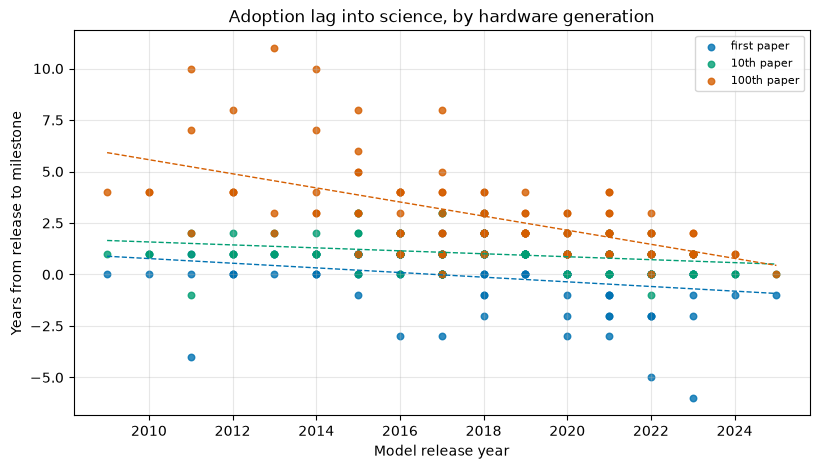

shape: (104, 6)
┌────────────────────────────────┬──────────────┬─────────────┬───────────┬────────┬─────────┐
│ display                        ┆ release_year ┆ segment     ┆ lag_first ┆ lag_10 ┆ lag_100 │
│ ---                            ┆ ---          ┆ ---         ┆ ---       ┆ ---    ┆ ---     │
│ str                            ┆ i64          ┆ str         ┆ i64       ┆ i64    ┆ i64     │
╞════════════════════════════════╪══════════════╪═════════════╪═══════════╪════════╪═════════╡
│ NVIDIA C1060                   ┆ 2009         ┆ datacenter  ┆ 0         ┆ 1      ┆ 4       │
│ NVIDIA GeForce GTX 580         ┆ 2010         ┆ consumer    ┆ 1         ┆ 1      ┆ 4       │
│ NVIDIA GeForce GTX 480         ┆ 2010         ┆ consumer    ┆ 0         ┆ 1      ┆ 4       │
│ NVIDIA C2050                   ┆ 2011         ┆ datacenter  ┆ -4        ┆ -1     ┆ 2       │
│ NVIDIA C2070                   ┆ 2011         ┆ datacenter  ┆ 0         ┆ 1      ┆ 7       │
│ NVIDIA C2075                   ┆

In [7]:
rows = []
for mid in elig['canonical_model']:
    d = meta.filter(pl.col('canonical_model') == mid).row(0, named=True)
    if not d['release_year']:
        continue
    s = (pm.filter(pl.col('canonical_model') == mid)
         .group_by('year').agg(k=pl.col('corpusid').n_unique()).sort('year'))
    if not s.height:
        continue
    cum, milestones = 0, {}
    for y, k in zip(s['year'], s['k']):
        cum += k
        for thr in (1, 10, 100):
            if thr not in milestones and cum >= thr:
                milestones[thr] = y - d['release_year']
    rows.append({'display': d['display'], 'release_year': d['release_year'],
                 'segment': d['segment'],
                 'lag_first': milestones.get(1), 'lag_10': milestones.get(10),
                 'lag_100': milestones.get(100)})
lag = pl.DataFrame(rows).filter(pl.col('lag_first').is_not_null())
fig, ax = plt.subplots(figsize=(9.5, 5))
for lbl, col, c in [('first paper', 'lag_first', '#0072B2'),
                    ('10th paper', 'lag_10', '#009E73'),
                    ('100th paper', 'lag_100', '#D55E00')]:
    s = lag.filter(pl.col(col).is_not_null())
    ax.scatter(s['release_year'], s[col], s=22, label=lbl, color=c, alpha=0.8)
    if s.height > 3:
        z = np.polyfit(s['release_year'].to_numpy(), s[col].to_numpy().astype(float), 1)
        xs = np.array([s['release_year'].min(), s['release_year'].max()])
        ax.plot(xs, np.polyval(z, xs), color=c, ls='--', lw=1)
ax.set(xlabel='Model release year', ylabel='Years from release to milestone',
       title='Adoption lag into science, by hardware generation')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()
with pl.Config(tbl_rows=30, fmt_str_lengths=34):
    print(lag.sort('release_year'))

### Validity check: pre-release mentions

A paper cannot legitimately use a chip released after it was published, so the
pre-release rate is a direct measurement-validity probe (the plan requires
flagging, not silently dropping, these).

Audited on the full run: **~0.08% of used-model observations are pre-release**
(102 at -1 year, 21 at -2, 11 at -3 or earlier). Identified causes: S2ORC year
metadata errors (one paper dated **1970** — a Unix-epoch default), preprint /
version date mismatches, and a handful of registry release dates that are a
year off. Negligible for aggregate trends, but they distort `lag_first` in the
adoption-lag table above, which is why lags there should be read with the
pre-release rows excluded.

In [8]:
# pre-release audit + clipped adoption lags
pmv = pm.filter(pl.col('release_year').is_not_null() & (pl.col('year') >= 1990))
pmv = pmv.with_columns(gap=pl.col('year') - pl.col('release_year'))
pre = pmv.filter(pl.col('gap') < 0)
print(f'used-model observations (year >= 1990): {pmv.height:,}')
print(f'pre-release: {pre.height:,} ({100*pre.height/pmv.height:.3f}%)')
print(pre.group_by('gap').len().sort('gap'))
print('\nmost affected models:')
print(pre.group_by('display').len().sort('len', descending=True).head(8))
bad_year = pm.filter(pl.col('year') < 1990)
print(f'\npapers with implausible year (<1990), excluded here: {bad_year.height}')

lag_clean = (lag.with_columns(
    pl.col('lag_first').clip(0, None), pl.col('lag_10').clip(0, None),
    pl.col('lag_100').clip(0, None)))
print('\nadoption lag (pre-release clipped to 0), medians by release era:')
print(lag_clean.with_columns(
        era=pl.when(pl.col('release_year') < 2015).then(pl.lit('pre-2015'))
        .when(pl.col('release_year') < 2020).then(pl.lit('2015-2019'))
        .otherwise(pl.lit('2020+')))
      .group_by('era').agg(n=pl.len(), med_first=pl.col('lag_first').median(),
                           med_10=pl.col('lag_10').median(),
                           med_100=pl.col('lag_100').median()).sort('era'))

used-model observations (year >= 1990): 197,376
pre-release: 99 (0.050%)
shape: (6, 2)
┌─────┬─────┐
│ gap ┆ len │
│ --- ┆ --- │
│ i64 ┆ u32 │
╞═════╪═════╡
│ -6  ┆ 1   │
│ -5  ┆ 1   │
│ -4  ┆ 1   │
│ -3  ┆ 5   │
│ -2  ┆ 16  │
│ -1  ┆ 75  │
└─────┴─────┘

most affected models:
shape: (8, 2)
┌────────────────────────────┬─────┐
│ display                    ┆ len │
│ ---                        ┆ --- │
│ str                        ┆ u32 │
╞════════════════════════════╪═════╡
│ NVIDIA GeForce RTX 3090 Ti ┆ 32  │
│ NVIDIA C2050               ┆ 10  │
│ NVIDIA A100                ┆ 5   │
│ NVIDIA GeForce RTX 5090    ┆ 4   │
│ Apple M1                   ┆ 4   │
│ NVIDIA V100                ┆ 4   │
│ Apple M2                   ┆ 4   │
│ AMD MI210                  ┆ 3   │
└────────────────────────────┴─────┘

papers with implausible year (<1990), excluded here: 0

adoption lag (pre-release clipped to 0), medians by release era:
shape: (3, 5)
┌───────────┬─────┬───────────┬────────┬─────────┐
│ e

## 6.4 Citation and disruption support

`citations_5y` (`i_5`) and `disruption_5y` (`cd_5`, the CD index) attributed to
each model, full and fractional. Restricted to papers with a **complete 5-year
window** (published ≤ 2020) so recent chips are not penalised for youth — the
single most important restriction in this section.

26,262 paper-model obs with complete 5-yr window and outcomes


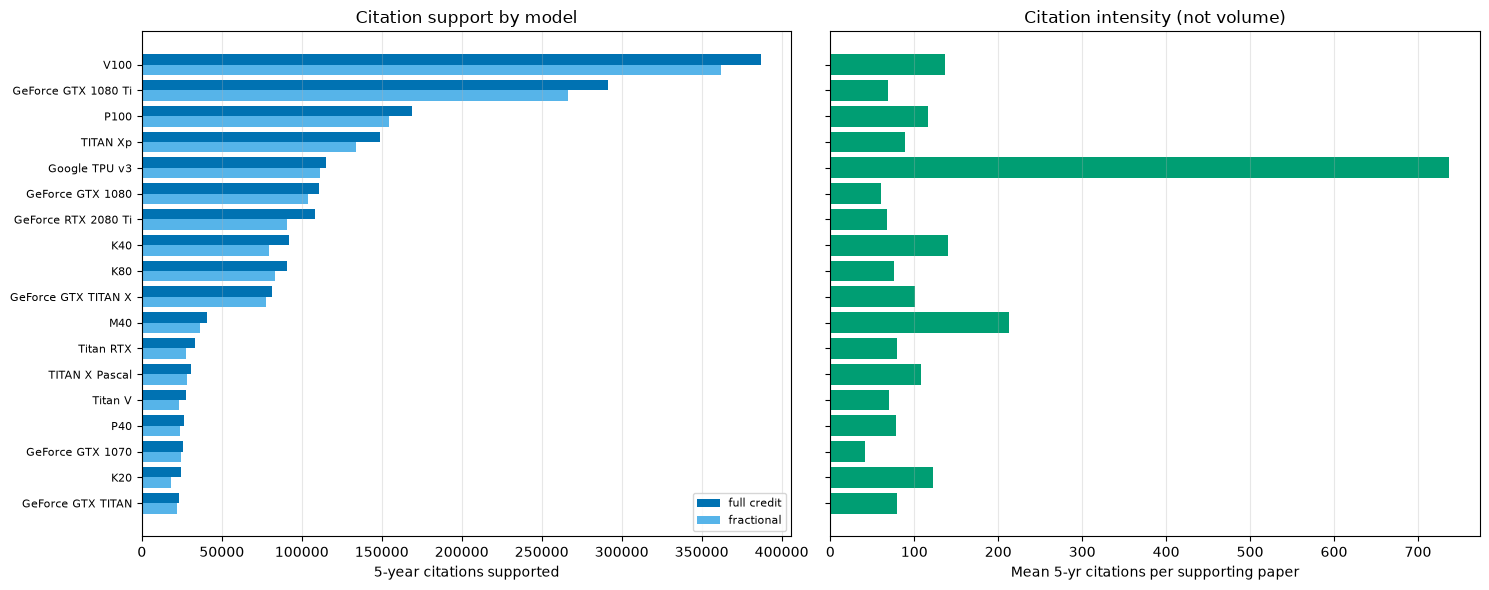

shape: (25, 8)
┌────────────┬────────────┬────────┬────────────┬────────────┬────────────┬────────────┬───────────┐
│ display    ┆ release_ye ┆ papers ┆ cites_full ┆ cites_frac ┆ cites_mean ┆ cites_medi ┆ disrupt_m │
│ ---        ┆ ar         ┆ ---    ┆ ---        ┆ ---        ┆ ---        ┆ an         ┆ edian     │
│ str        ┆ ---        ┆ u32    ┆ i64        ┆ f64        ┆ f64        ┆ ---        ┆ ---       │
│            ┆ i32        ┆        ┆            ┆            ┆            ┆ f64        ┆ f64       │
╞════════════╪════════════╪════════╪════════════╪════════════╪════════════╪════════════╪═══════════╡
│ NVIDIA     ┆ 2017       ┆ 2837   ┆ 386822     ┆ 361906.0   ┆ 136.3      ┆ 25.0       ┆ -0.000131 │
│ V100       ┆            ┆        ┆            ┆            ┆            ┆            ┆           │
│ NVIDIA     ┆ 2017       ┆ 4215   ┆ 291700     ┆ 266696.0   ┆ 69.2       ┆ 21.0       ┆ -0.000096 │
│ GeForce    ┆            ┆        ┆            ┆            ┆            ┆ 

In [9]:
cw = pm.filter(pl.col('window_complete') & pl.col('has_outcomes'))
print(f'{cw.height:,} paper-model obs with complete 5-yr window and outcomes')
cs = (cw.group_by('canonical_model', 'display', 'release_year')
      .agg(papers=pl.len(),
           cites_full=pl.col('citations_5y').sum(),
           cites_frac=(pl.col('citations_5y') * pl.col('frac')).sum(),
           cites_mean=pl.col('citations_5y').mean(),
           cites_median=pl.col('citations_5y').median(),
           disrupt_median=pl.col('disruption_5y').median())
      .filter(pl.col('papers') >= 30).sort('cites_full', descending=True))
top = cs.head(18)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
y = np.arange(top.height)
axes[0].barh(y - 0.2, top['cites_full'], 0.4, label='full credit', color='#0072B2')
axes[0].barh(y + 0.2, top['cites_frac'], 0.4, label='fractional', color='#56B4E9')
axes[0].set_yticks(y)
axes[0].set_yticklabels([d.replace('NVIDIA ', '') for d in top['display']], fontsize=8)
axes[0].invert_yaxis(); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis='x')
axes[0].set(xlabel='5-year citations supported', title='Citation support by model')
axes[1].barh(y, top['cites_mean'], color='#009E73')
axes[1].set_yticks(y); axes[1].set_yticklabels([]); axes[1].invert_yaxis()
axes[1].set(xlabel='Mean 5-yr citations per supporting paper',
            title='Citation intensity (not volume)')
axes[1].grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()
with pl.Config(tbl_rows=25, fmt_str_lengths=34):
    print(cs.select('display', 'release_year', 'papers', 'cites_full',
                    pl.col('cites_frac').round(0), pl.col('cites_mean').round(1),
                    pl.col('cites_median').round(1),
                    pl.col('disrupt_median').round(6)).head(25))

### Ranking stability: papers vs citations vs disruption

If a model's citation rank far exceeds its paper rank, a handful of famous
papers is doing the work. Comparing the three rankings is the honest way to
present "device productivity" without implying causality.

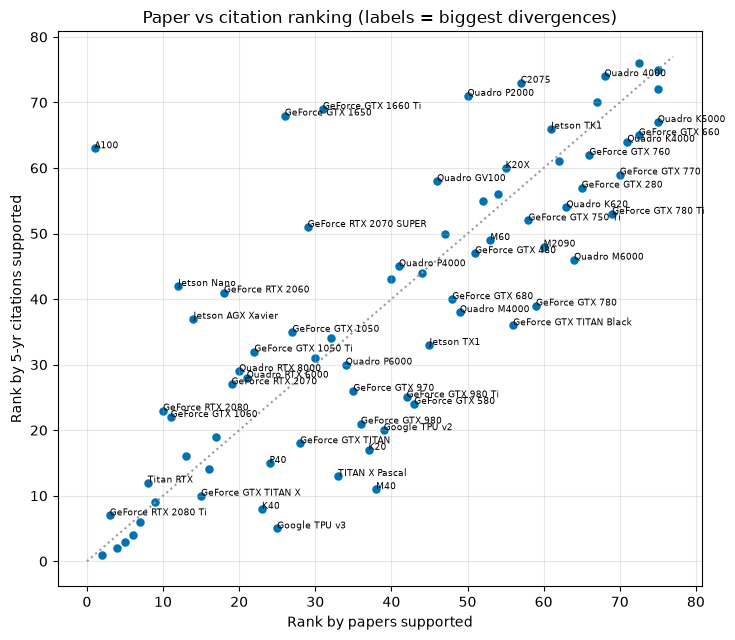

Spearman-style rank correlations:
  rank_papers vs rank_cites: 0.764
  rank_papers vs rank_intensity: 0.534
  rank_cites vs rank_disrupt: 0.062


In [10]:
rk = (cs.join(sup.select('canonical_model', 'papers_full'), on='canonical_model', how='left')
      .with_columns(rank_papers=pl.col('papers_full').rank(descending=True),
                    rank_cites=pl.col('cites_full').rank(descending=True),
                    rank_intensity=pl.col('cites_mean').rank(descending=True),
                    rank_disrupt=pl.col('disrupt_median').rank(descending=True)))
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(rk['rank_papers'], rk['rank_cites'], s=26, color='#0072B2')
lim = max(rk['rank_papers'].max(), rk['rank_cites'].max()) + 1
ax.plot([0, lim], [0, lim], ls=':', color='#999999')
for r in rk.iter_rows(named=True):
    if abs(r['rank_papers'] - r['rank_cites']) >= 4:
        ax.annotate(r['display'].replace('NVIDIA ', ''),
                    (r['rank_papers'], r['rank_cites']), fontsize=6.5)
ax.set(xlabel='Rank by papers supported', ylabel='Rank by 5-yr citations supported',
       title='Paper vs citation ranking (labels = biggest divergences)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('Spearman-style rank correlations:')
for a, b in [('rank_papers', 'rank_cites'), ('rank_papers', 'rank_intensity'),
             ('rank_cites', 'rank_disrupt')]:
    print(f'  {a} vs {b}: {np.corrcoef(rk[a].to_numpy(), rk[b].to_numpy())[0,1]:.3f}')